In [1]:
import torch
import torchvision
from torchvision.transforms import v2
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torchvision.transforms.functional as F
import numpy as np
from torchvision.utils import make_grid
from tqdm import trange, tqdm
from geometry_tools import lerp
from conditional_gmm import ConditionalGMM
from posterior_manifold import FisherLogPosteriorManifold
from conformal_ebm import optimize_ebm_geodesic
from utils import categorical_entropy, get_random_image, get_random_images, get_random_images_of_classes
from sklearn.mixture import GaussianMixture, BayesianGaussianMixture
import torch.distributions as D
from utils import NestedDiagonalGMM
transform = v2.Compose([
    v2.Resize((128, 128), interpolation=v2.InterpolationMode.BICUBIC),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
])
def show_img(img, figsize=None, ax=None):
    if not ax:
        fig = plt.figure(figsize=figsize)
        ax = fig.add_subplot()
    img = img.detach()
    img = F.to_pil_image(img)
    ax.imshow(np.asarray(img), cmap='gray')
    ax.set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])

In [2]:
celeba = torchvision.datasets.CelebA(root='datasets', split='all', transform=transform, download=False)
celeba_loader = DataLoader(celeba, batch_size=16, shuffle=False, num_workers=4)

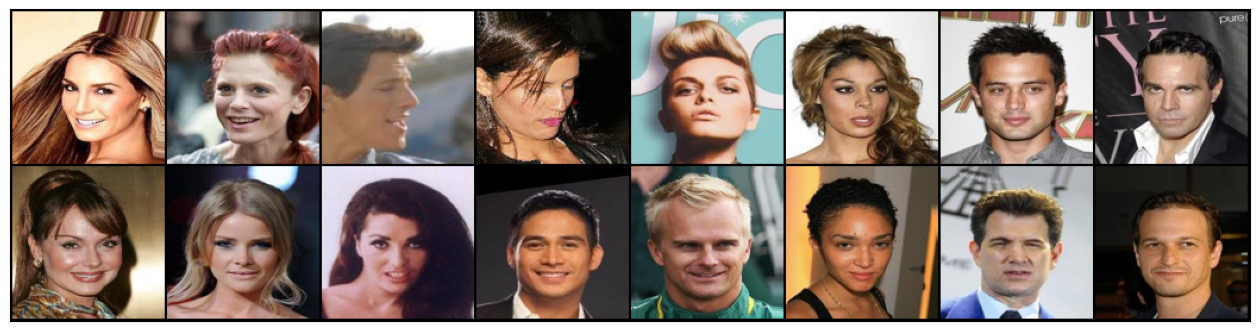

In [3]:
imgs, labels = next(celeba_loader.__iter__())
show_img(make_grid(imgs), figsize=(16, 8))

In [4]:
from pretrained_models import StableDiffusionVAE, CelebALatentVAE
diff_vae = StableDiffusionVAE()
latent_vae = CelebALatentVAE(n_latent=64)

/usr/people/robertwiebe/testvenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/usr/people/robertwiebe/testvenv/lib/python3.11/site-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/net/st1/export/clusterhome/robertwiebe/ml_geometry_project/repos/torch_vae_2/model.py:229: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future

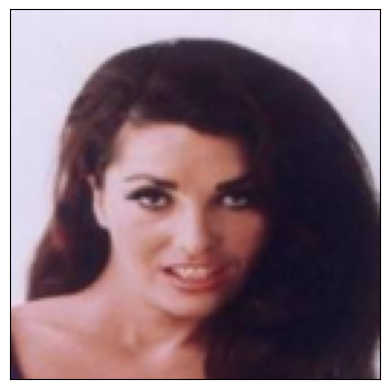

In [5]:
test_img = imgs[10]
show_img(test_img)

In [6]:
test_latent = diff_vae.encode(test_img)

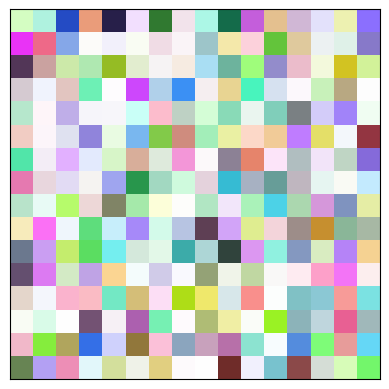

In [7]:
show_img(test_latent)

In [8]:
latent_reconstr = latent_vae.reconstruct(test_latent)

In [9]:
latent_reconstr.shape

torch.Size([4, 16, 16])

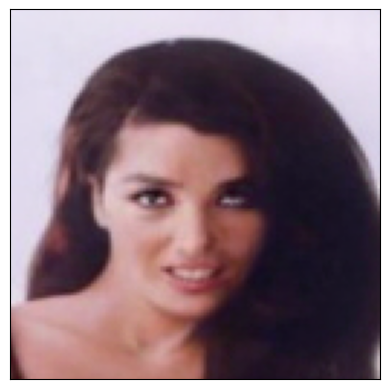

In [9]:
show_img(diff_vae.reconstruct(test_img))

In [22]:
recostr = diff_vae.decode(latent_reconstr)

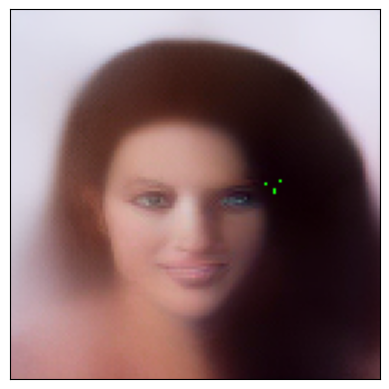

In [ ]:
show_img(recostr)

In [10]:
test_latent

tensor([[[ 21.4520,  12.4552,  11.1625,  ...,  11.2452,  11.8701,   8.5145],
         [ 14.9528,   9.9462,   6.5209,  ...,   9.1865,   9.0626,  10.1528],
         [ 12.3339,  11.5529,  11.8189,  ...,  12.8768,   9.8441,   9.6966],
         ...,
         [  8.7742,  10.7914,   5.0759,  ...,   3.2408,   2.9093,   1.4176],
         [  4.8576,   9.5091,  10.6006,  ...,   2.2816,   1.8515,   2.1242],
         [  4.4202,  10.4183,   6.9568,  ...,   1.3726,   0.6226,   3.3436]],

        [[ 14.0313,   9.9464,   7.3035,  ...,   7.1802,   5.8849,   8.3895],
         [ 12.0581,   6.2098,   6.6610,  ...,   8.4091,   4.5952,  11.0563],
         [  6.1922,   6.1502,   8.9347,  ...,   4.9361,   4.7617,   7.9313],
         ...,
         [  3.8716,   7.0026,   8.3869,  ...,  -4.5131,  -3.7425,  -0.4463],
         [  3.2055,   7.9542,   1.5089,  ...,  -3.0319,  -4.6617,   3.7855],
         [  4.5361,   2.2258,   3.5678,  ...,   0.4918,  -4.0510,   8.9949]],

        [[-18.9798,  -9.2742,  -2.2471,  ...

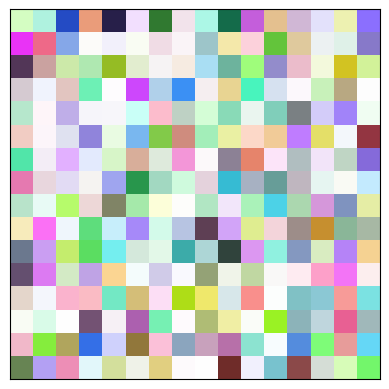

In [11]:
show_img(test_latent)

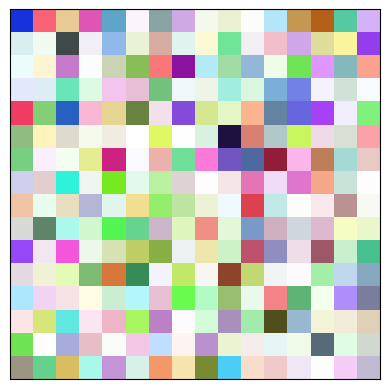

In [12]:
show_img(latent_reconstr)

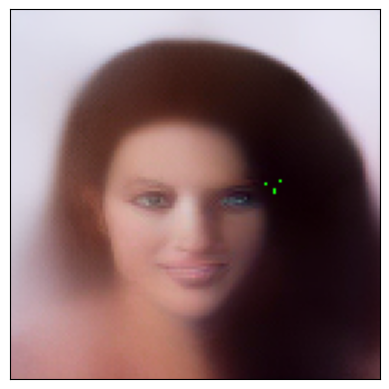

In [13]:
show_img(diff_vae.decode(latent_reconstr))

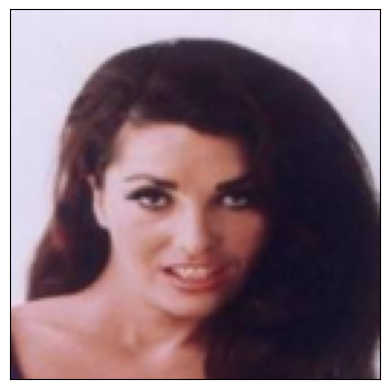

In [18]:
show_img(test_img)

In [ ]:
diff

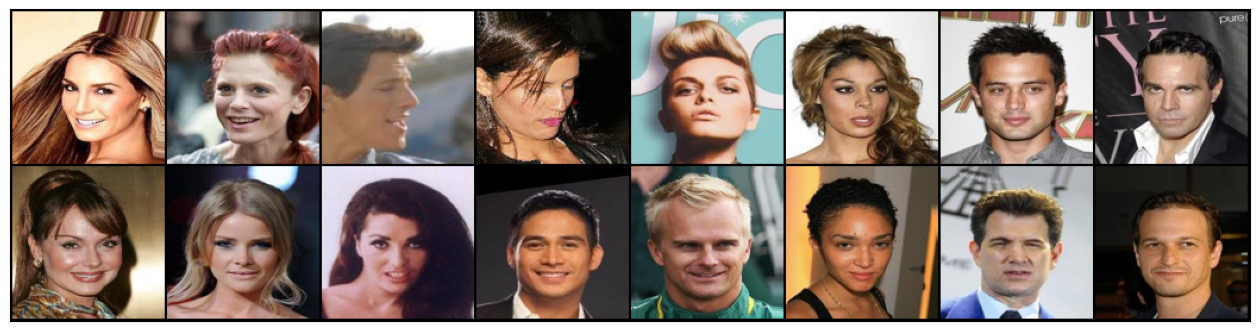

In [15]:
show_img(make_grid(imgs), figsize=(16, 8))

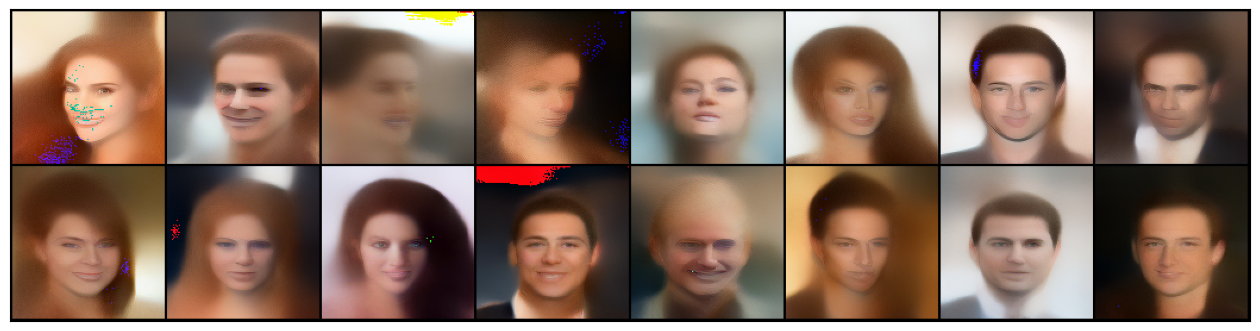

In [20]:
show_img(make_grid(
    diff_vae.decode(latent_vae.reconstruct(diff_vae.encode(imgs)))
), figsize=(16, 8))

In [19]:
from torchmetrics.image import StructuralSimilarityIndexMeasure as ssim

In [ ]:
ssim()